In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown='ignore')
import warnings
warnings.filterwarnings("ignore")

# pd.set_option("display.width", 150) 
# pd.set_option("display.precision", 3)
# plt.rcParams["figure.figsize"] = (9, 4.2)
# plt.rcParams["axes.grid"] = True
# plt.rcParams["grid.alpha"] = 0.3
# plt.rcParams["figure.dpi"] = 110

SEED = 42

In [40]:
df = pd.read_csv("online_shoppers_intention.csv")
df.head(10)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
6,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.4,Feb,2,4,3,3,Returning_Visitor,False,False
7,1,0.0,0,0.0,0,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,2,1,5,Returning_Visitor,True,False
8,0,0.0,0,0.0,2,37.000000,0.000000,0.100000,0.0,0.8,Feb,2,2,2,3,Returning_Visitor,False,False
9,0,0.0,0,0.0,3,738.000000,0.000000,0.022222,0.0,0.4,Feb,2,4,1,2,Returning_Visitor,False,False


In [3]:
df.shape

(12330, 18)

# EDA

## Первичная обработка

In [41]:
print('Все колонки:', df.columns.tolist())
df.info()

Все колонки: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']
<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9 

In [42]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [43]:
target_feature = 'Revenue'

categ_features = [
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Month"
]

binary_features = [
    "Weekend"
]

quant_features = [
    'Administrative',
    'Administrative_Duration',
    'Informational',
    'Informational_Duration',
    'ProductRelated',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues',
    'SpecialDay'
]

print(set(categ_features + binary_features + quant_features + [target_feature]) == set(df.columns.to_list()) and len(categ_features) + len(binary_features) + len(quant_features) + 1 == len(df.columns.to_list()))


True


In [44]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Кол-во пропусков': missing,
    'Процент': missing_pct
})
print(missing_df)

Empty DataFrame
Columns: [Кол-во пропусков, Процент]
Index: []


In [45]:
total_duplicates = df.duplicated().sum()
print(f"Всего дублирующихся строк: {total_duplicates}")

Всего дублирующихся строк: 125


In [46]:
df.drop_duplicates(inplace=True)

## Распределение

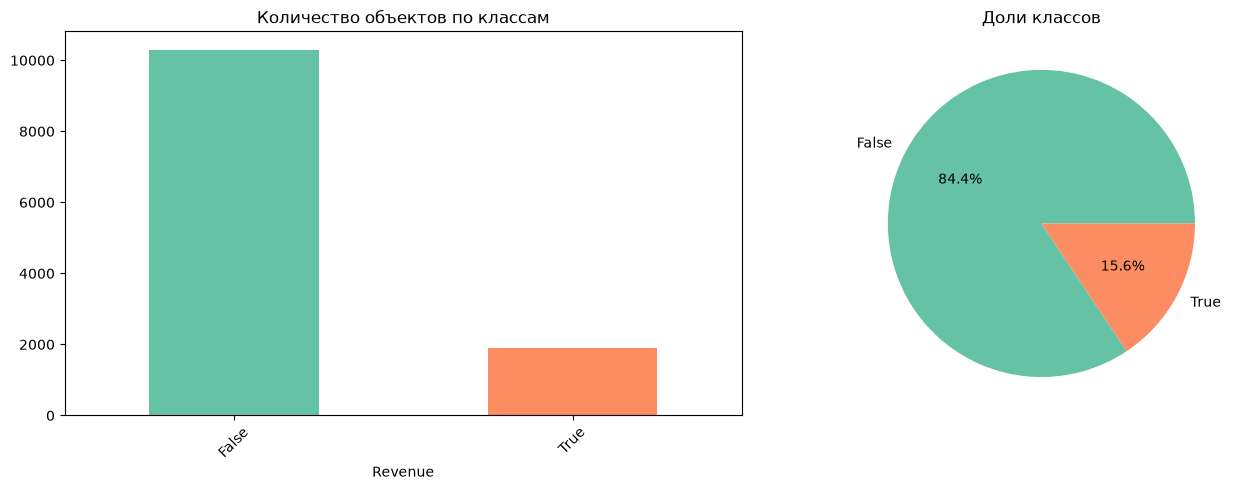

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[target_feature].value_counts().plot.bar(ax=axes[0], color=sns.color_palette('Set2'))
axes[0].set_title('Количество объектов по классам')
axes[0].tick_params(axis='x', rotation=45)

df[target_feature].value_counts(normalize=True).plot.pie(ax=axes[1], autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1].set_ylabel('')
axes[1].set_title('Доли классов')
plt.tight_layout()
plt.show()

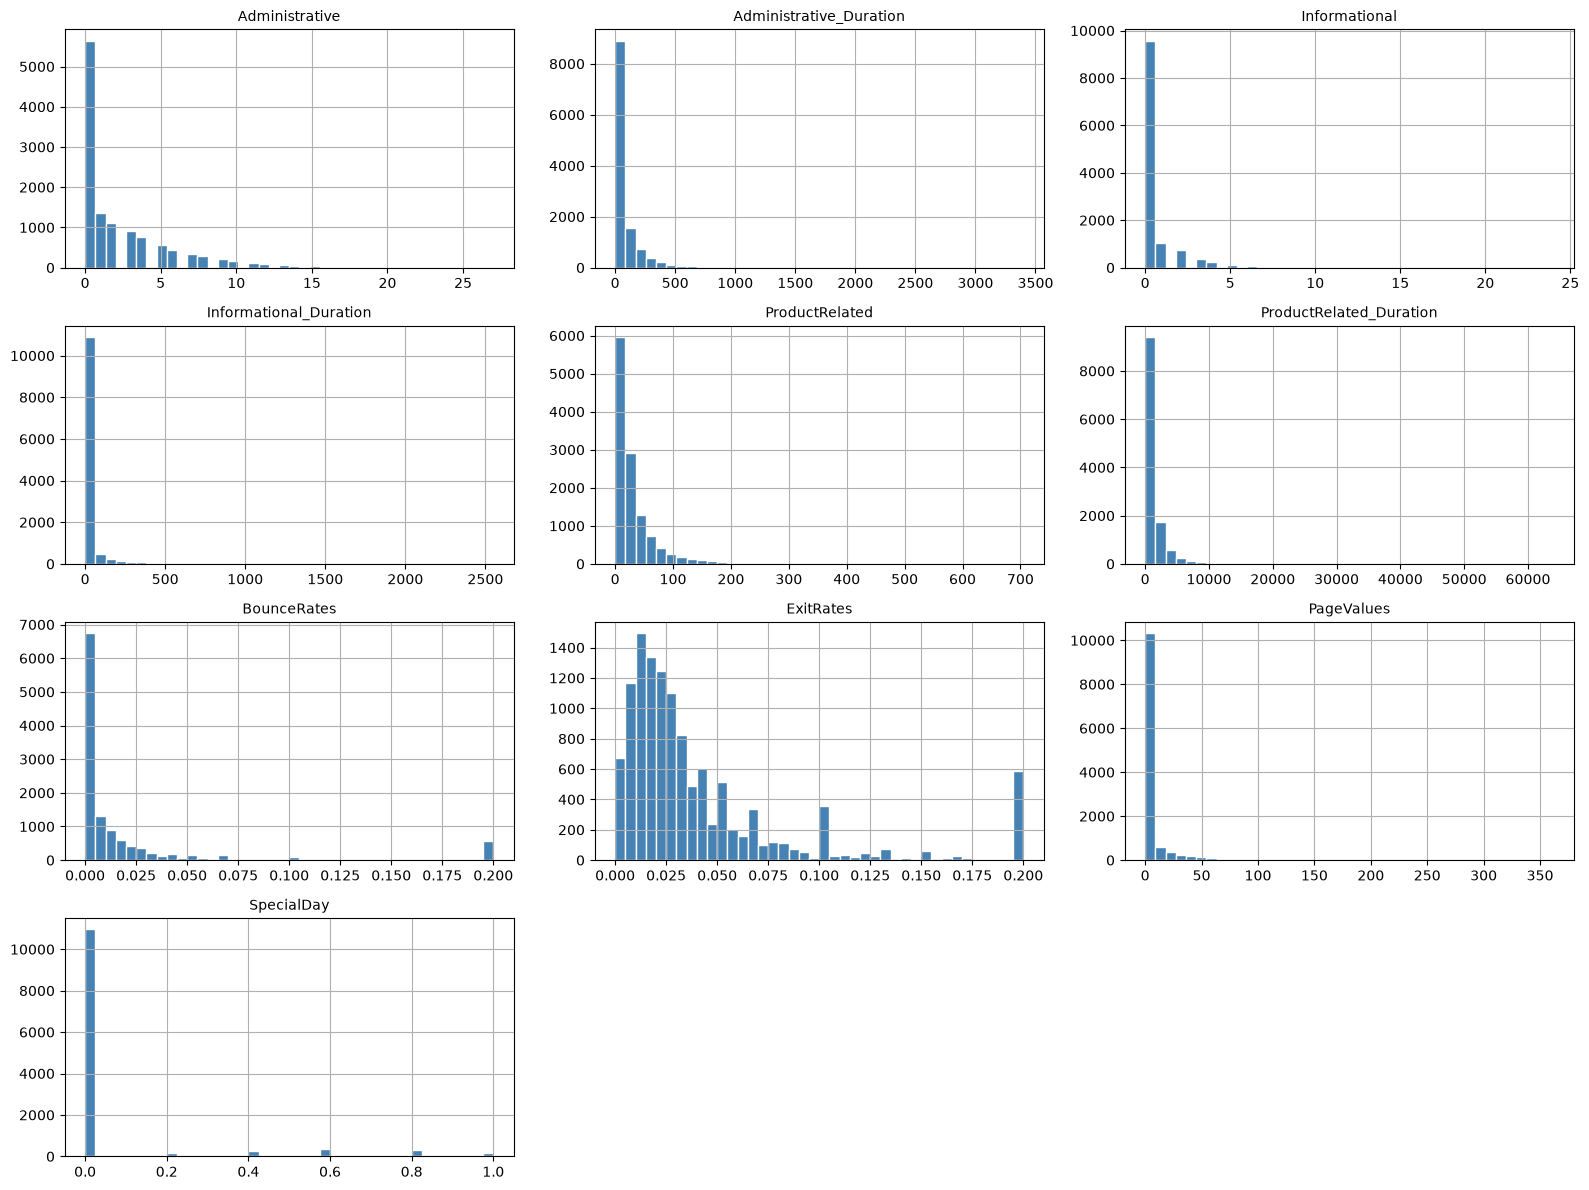

In [48]:
n_cols = len(quant_features)
n_rows = (n_cols + 2) // 3
fig, axes = plt.subplots(n_rows, 3, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(quant_features):
    df[col].hist(bins=40, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)

for j in range(len(quant_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [49]:
df[list(quant_features)].describe(percentiles=[.05, .25, .50, .75, .95, .99]).T

,count,mean,std,min,5%,25%,50%,75%,95%,99%,max
Administrative,12205.0,2.338878,3.330436,0.0,0.000000,0.000000,1.000000,4.000000,9.000000,14.000000,27.000000
Administrative_Duration,12205.0,81.646331,177.491845,0.0,0.000000,0.000000,9.000000,94.700000,352.208095,838.704889,3398.750000
Informational,12205.0,0.508726,1.275617,0.0,0.000000,0.000000,0.000000,0.000000,3.000000,6.000000,24.000000
Informational_Duration,12205.0,34.825454,141.424807,0.0,0.000000,0.000000,0.000000,0.000000,199.000000,722.379200,2549.375000
ProductRelated,12205.0,32.045637,44.593649,0.0,2.000000,8.000000,18.000000,38.000000,110.000000,221.000000,705.000000
ProductRelated_Duration,12205.0,1206.982457,1919.601400,0.0,0.000000,193.000000,608.942857,1477.154762,4312.956282,8704.271573,63973.522230
BounceRates,12205.0,0.020370,0.045255,0.0,0.000000,0.000000,0.002899,0.016667,0.149333,0.200000,0.200000
ExitRates,12205.0,0.041466,0.046163,0.0,0.004545,0.014231,0.025000,0.048529,0.173714,0.200000,0.200000
PageValues,12205.0,5.949574,18.653671,0.0,0.000000,0.000000,0.000000,0.000000,38.301457,86.108689,361.763742
SpecialDay,12205.0,0.061942,0.199666,0.0,0.000000,0.000000,0.000000,0.000000,0.600000,1.000000,1.000000


In [50]:
features = [
   'PageValues', 
   'ProductRelated_Duration',
   'ProductRelated',
   'Administrative_Duration',
   'Informational_Duration',
]

for i in features:
    df['Log_' + i] = np.log1p(df[i])

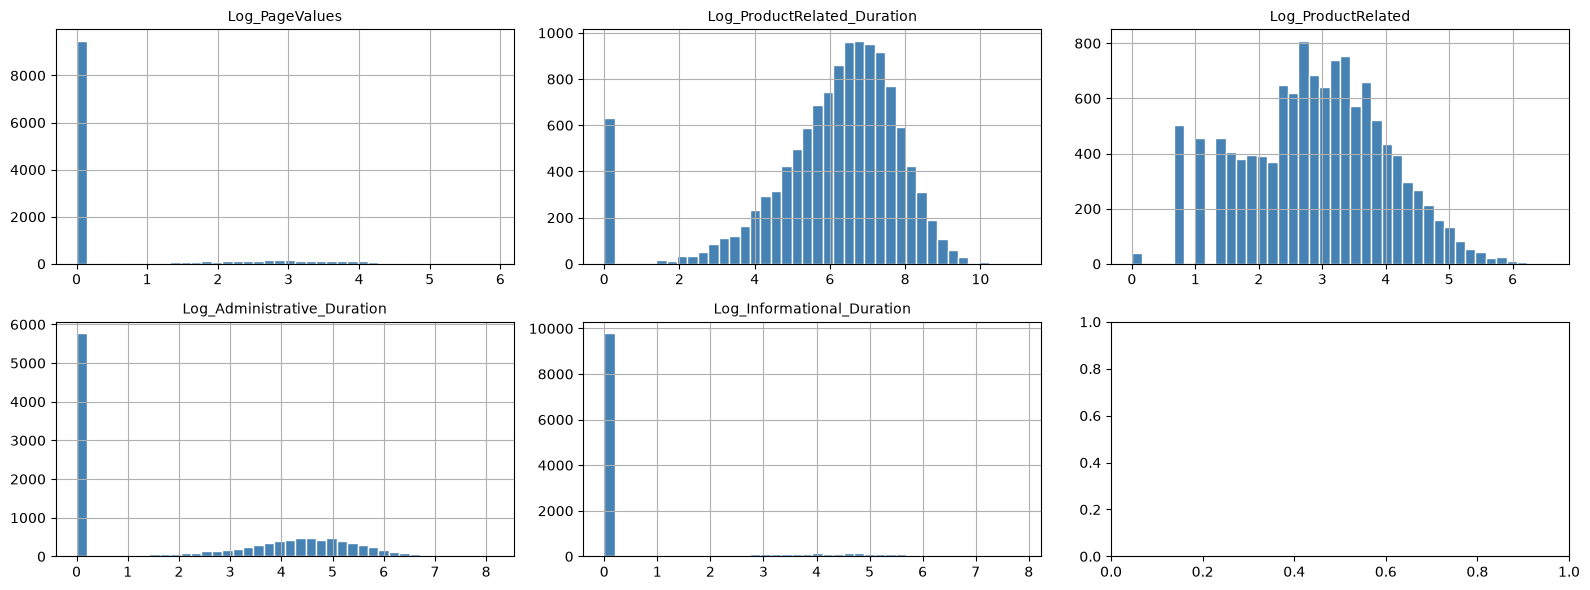

In [51]:
log_features = ['Log_' + i for i in features]

n_cols = len(log_features)
n_rows = (n_cols + 2) // 3
fig, axes = plt.subplots(n_rows, 3, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(log_features):
    df[col].hist(bins=40, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)

for j in range(len(quant_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

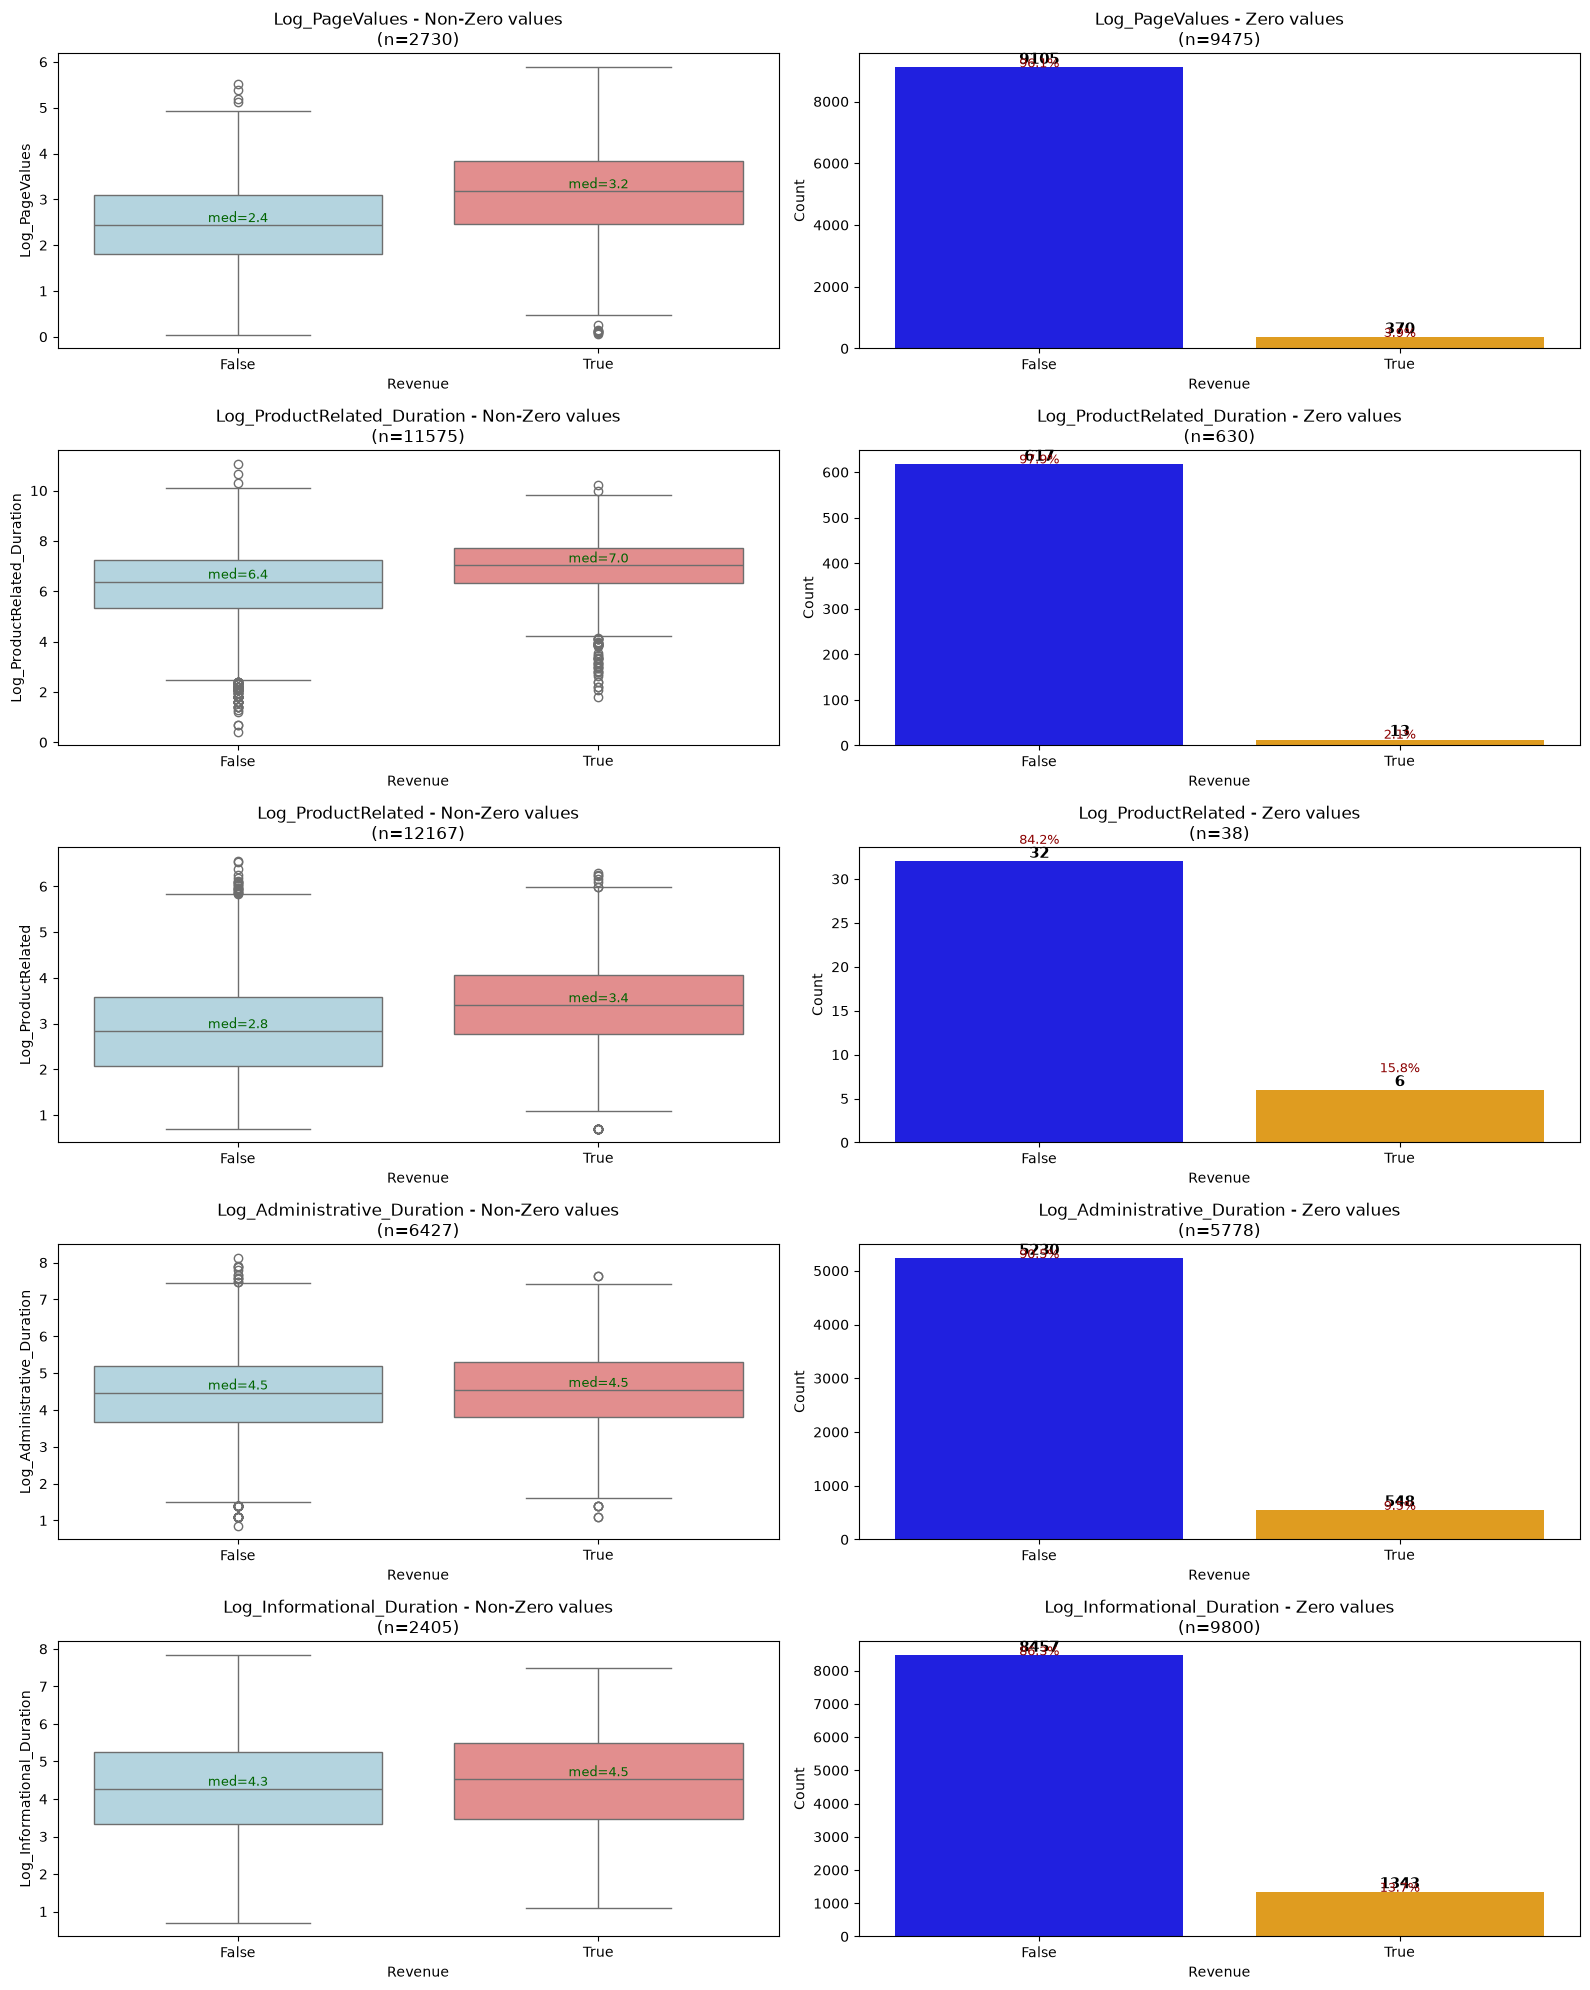

In [52]:
fig, axes = plt.subplots(len(log_features), 2, figsize=(16, 20))

for i, feature in enumerate(log_features):
    # --- Boxplot для Non-Zero ---
    nonzero_data = df[df[feature] != 0]
    if len(nonzero_data) > 0:
        # Добавляем статистику на график
        stats = nonzero_data.groupby('Revenue')[feature].describe()
        sns.boxplot(data=nonzero_data, x='Revenue', y=feature, 
                    ax=axes[i, 0], palette=['lightblue', 'lightcoral'])
        axes[i, 0].set_title(f'{feature} - Non-Zero values\n(n={len(nonzero_data)})')
        axes[i, 0].set_ylabel(feature)
        # Добавляем медиану на график
        for j, rev in enumerate([False, True]):
            if rev in stats.index:
                median = stats.loc[rev, '50%']
                axes[i, 0].text(j, median, f'med={median:.1f}', 
                               ha='center', va='bottom', fontsize=9, color='darkgreen')
    
    # --- Гистограмма для Zero ---
    zero_data = df[df[feature] == 0]
    if len(zero_data) > 0:
        ax = axes[i, 1]
        # Используем countplot так как все значения = 0
        sns.countplot(data=zero_data, x='Revenue', ax=ax, 
                      palette=['blue', 'orange'])
        ax.set_title(f'{feature} - Zero values\n(n={len(zero_data)})')
        ax.set_ylabel('Count')
        ax.set_xlabel('Revenue')
        # Добавляем значения
        for container in ax.containers:
            ax.bar_label(container, fontsize=11, fontweight='bold')
        
        # Добавляем процентное соотношение
        total = len(zero_data)
        for j, p in enumerate(ax.patches):
            height = p.get_height()
            percentage = f'{(height/total)*100:.1f}%'
            ax.text(p.get_x() + p.get_width()/2., height + 2, 
                   percentage, ha='center', fontsize=9, color='darkred')

plt.tight_layout()
plt.show()


## Категориальные фичи

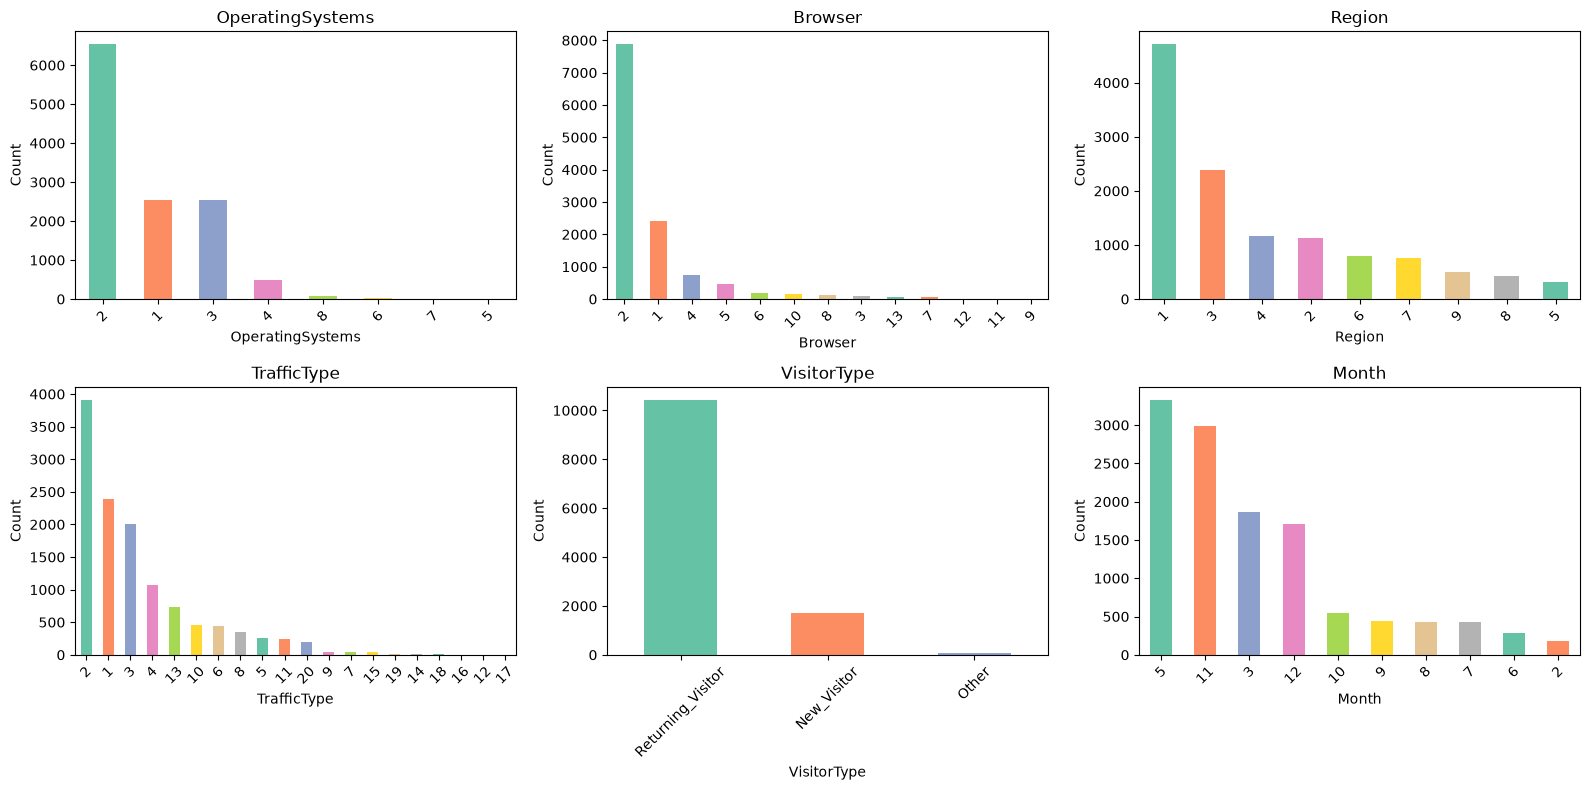

In [33]:
n_cols = 3
n_rows = (len(categ_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(categ_features):
    df[col].value_counts().plot.bar(ax=axes[i], color=sns.color_palette('Set2'))
    axes[i].set_title(col, fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('Count')

for j in range(len(categ_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

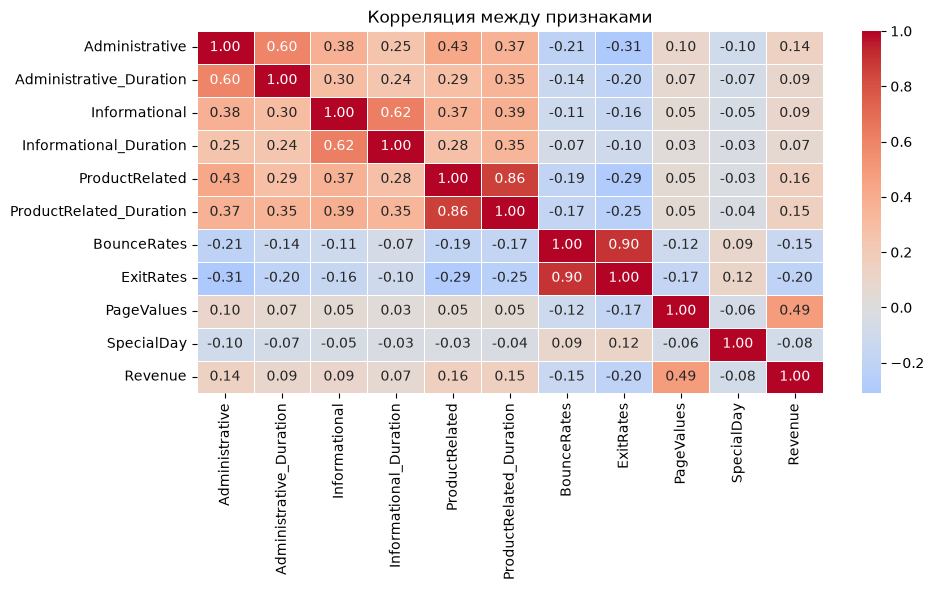

In [35]:
plt.figure(figsize=(10, 6))
corr = df[quant_features + [target_feature]].corr()
# mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Корреляция между признаками')
plt.tight_layout()
plt.show()

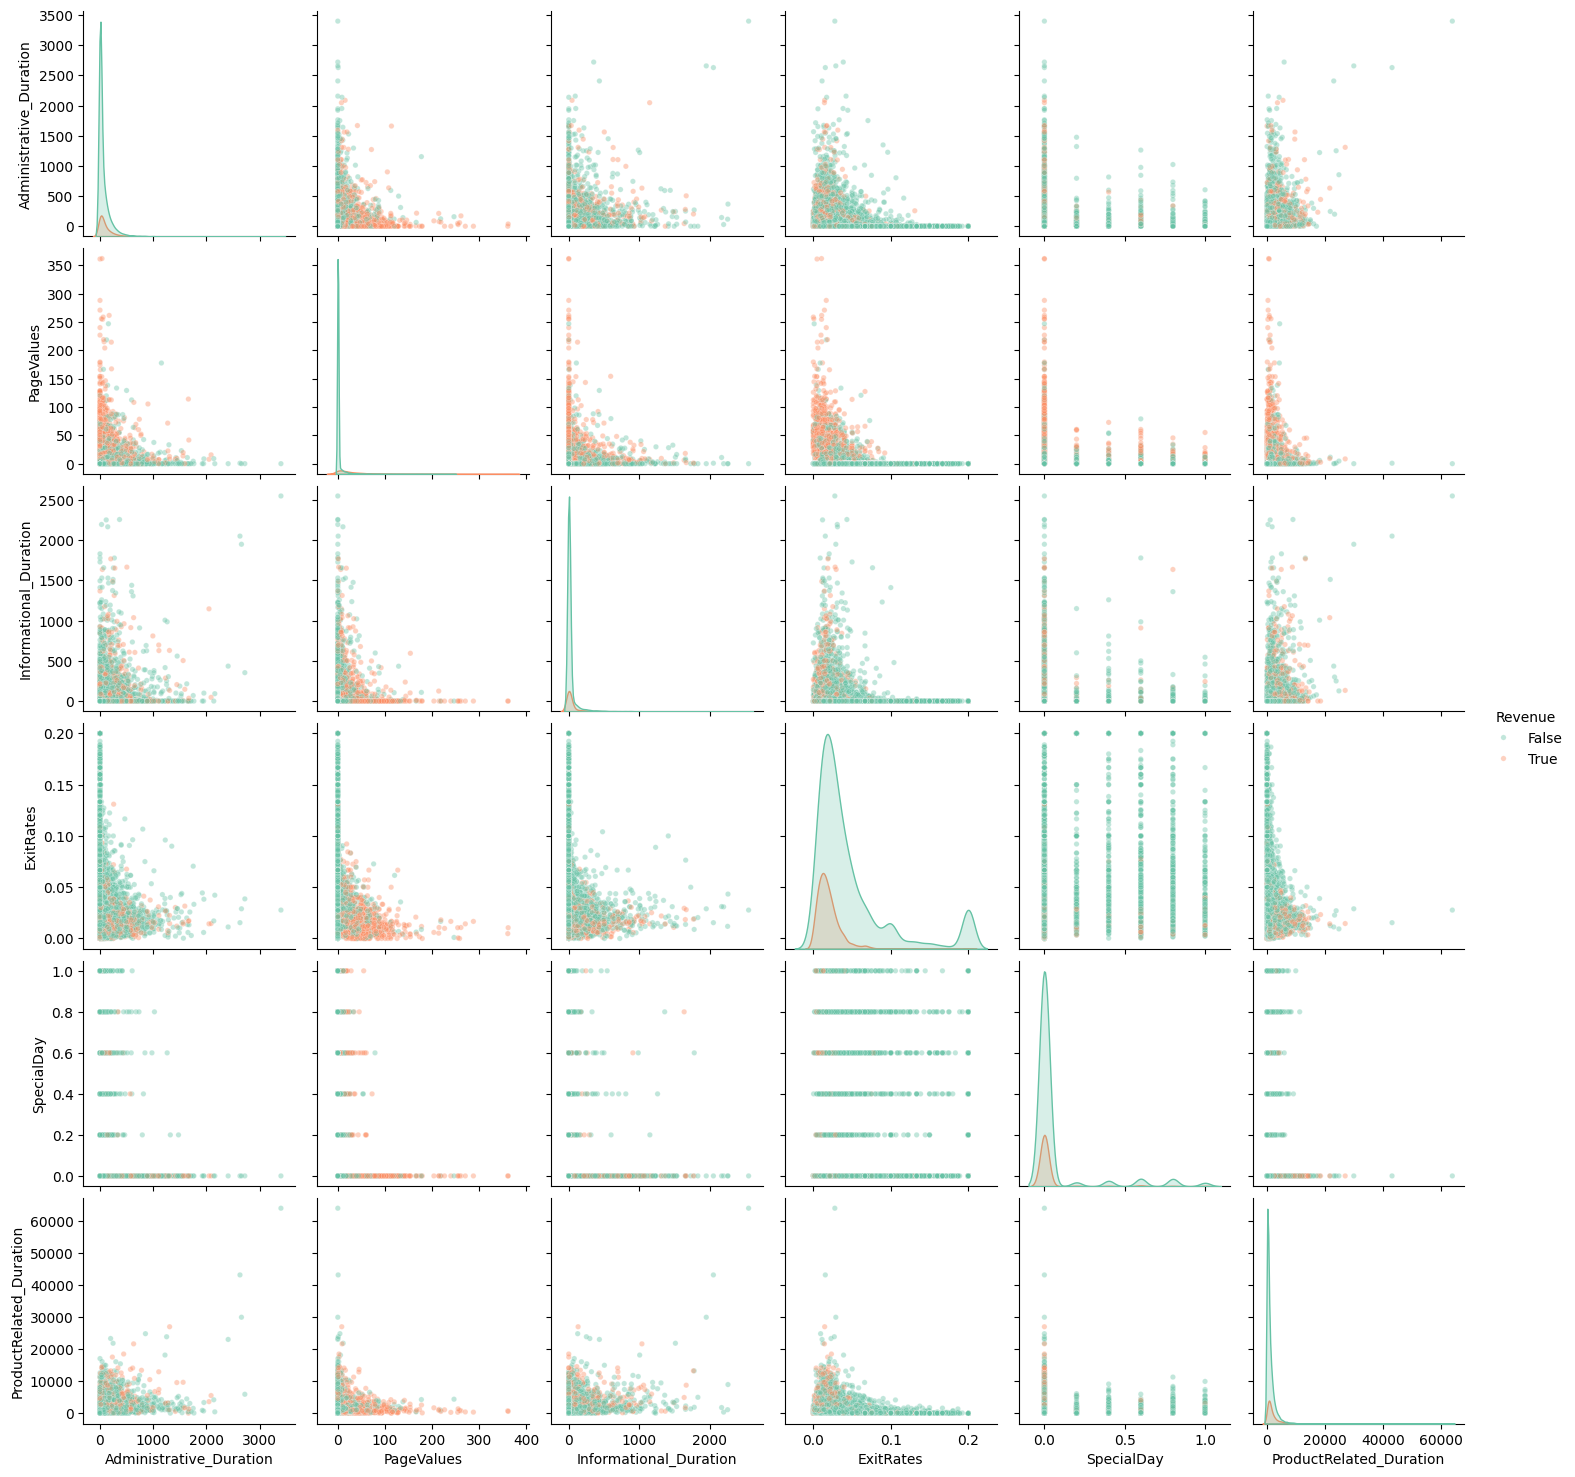

In [ ]:
col = [
    'Administrative_Duration',
    'PageValues',
    'Informational_Duration',
    'ExitRates',
    'SpecialDay',
    'ProductRelated_Duration',
     target_feature
]

sns.pairplot(
    df[col],
    hue=target_feature,
    palette='Set2',
    plot_kws={'alpha': 0.4, 's': 15}
  )

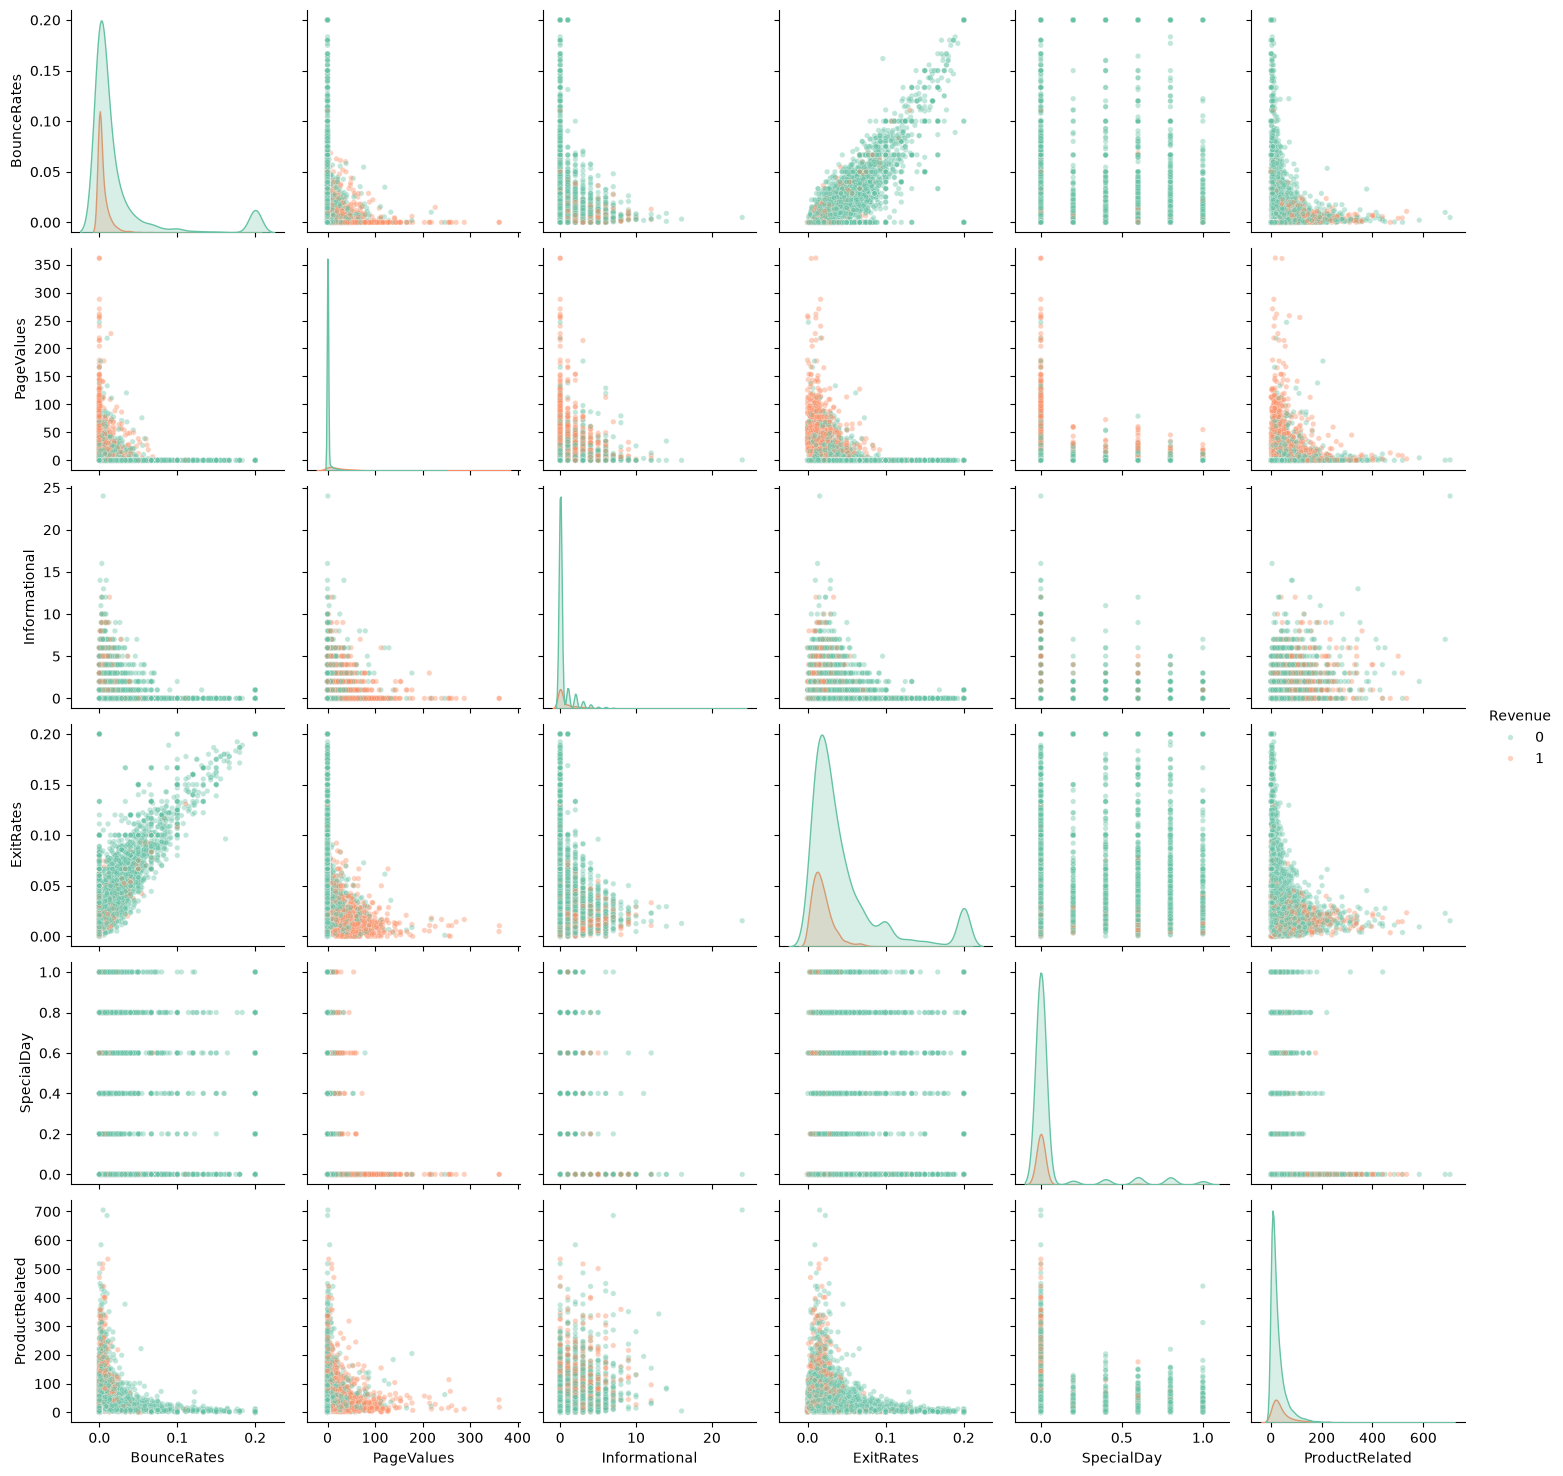

In [62]:
col = [
    'BounceRates',
    'PageValues',
    'Informational',
    'ExitRates',
    'SpecialDay',
    'ProductRelated',
     target_feature
]

sns.pairplot(
    df[col],
    hue=target_feature,
    palette='Set2',
    plot_kws={'alpha': 0.4, 's': 15}
  )

# Feature engineering

In [53]:
df[['Revenue', 'Weekend']] = df[['Revenue', 'Weekend']].astype(int)

In [54]:
month_to_num = {
    'Jan': 1,
    'Feb': 2,
    'Mar': 3,
    'Apr': 4,
    'May': 5,
    'June': 6,
    'Jul': 7,
    'Aug': 8,
    'Sep': 9,
    'Oct': 10,
    'Nov': 11,
    'Dec': 12
}

df['Month'] = df['Month'].map(month_to_num)

In [56]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Region,TrafficType,VisitorType,Weekend,Revenue,Log_PageValues,Log_ProductRelated_Duration,Log_ProductRelated,Log_Administrative_Duration,Log_Informational_Duration
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,1,1,Returning_Visitor,0,0,0.0,0.000000,0.693147,0.0,0.0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,1,2,Returning_Visitor,0,0,0.0,4.174387,1.098612,0.0,0.0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,9,3,Returning_Visitor,0,0,0.0,0.000000,0.693147,0.0,0.0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,2,4,Returning_Visitor,0,0,0.0,1.299283,1.098612,0.0,0.0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,1,4,Returning_Visitor,1,0,0.0,6.443336,2.397895,0.0,0.0


In [26]:
df.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='str')

In [54]:
categ_features

{'Browser',
 'Month',
 'OperatingSystems',
 'Region',
 'TrafficType',
 'VisitorType',
 'Weekend'}

In [121]:
df['VisitorType'].value_counts()

VisitorType
Returning_Visitor    10431
New_Visitor           1693
Other                   81
Name: count, dtype: int64

In [ ]:
for col in (categ_features):
    counts = df[col].value_counts()
    rare_categories = counts[counts < 10].index

    df.loc[
        df[col].isin(rare_categories),
        col
    ] = 'Other'

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

In [64]:
df.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue', 'ProductRelated_Duration_log',
       'Informational_Duration_log', 'ProductRelated_log', 'PageValues_log',
       'Administrative_Duration_log', 'AddInfo_Duration_log'],
      dtype='str')

In [ ]:
X = df[[]]
y = df[target_feature]

In [108]:
ct = ColumnTransformer([
    ('visitor_encoder', OneHotEncoder(), ['VisitorType'])
], remainder='passthrough')


In [127]:
X_encoded = ct.fit_transform(X)

In [102]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

In [128]:
X_train, X_test, y_train, y_test =  train_test_split(X_encoded, y, test_size=0.2, random_state=SEED, stratify=y)

In [129]:
tree = DecisionTreeClassifier(random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(tree, X_train, y_train, cv=cv, scoring='f1')

print(f"Средний F1: {scores.mean():.3f} (+/- {scores.std():.3f})")

Средний F1: 0.554 (+/- 0.011)
